In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df =pd.read_csv("../outputs/feature_sets.csv")

summary = (
    df.groupby("k")
    .agg(
        mean_r2 = ("r2", "mean"),
        sd_r2 = ("r2", "std"),
        mean_mse=("mse", "mean"),
        sd_mse=("mse", "std"),
    )
    .reset_index()
)

In [4]:
summary

,k,mean_r2,sd_r2,mean_mse,sd_mse
0,1,0.011235,0.042390,0.416644,0.017862
1,2,0.020271,0.058365,0.412837,0.024594
2,3,0.023501,0.060790,0.411475,0.025615
3,5,0.030673,0.066801,0.408453,0.028149
4,9,0.065567,0.085789,0.393750,0.036150
5,13,0.093314,0.093543,0.382058,0.039417
6,21,0.134274,0.109148,0.364798,0.045993
7,33,0.178625,0.102846,0.346110,0.043337
8,52,0.232334,0.098511,0.323478,0.041510
9,81,0.254425,0.093048,0.314169,0.039208


<Axes: xlabel='k'>

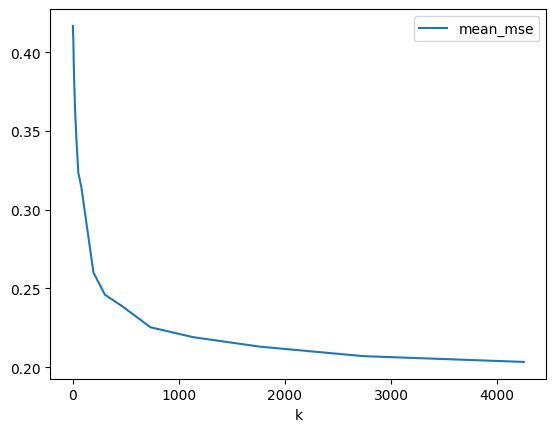

In [9]:
summary.plot(x='k', y='mean_mse')

<Axes: xlabel='k'>

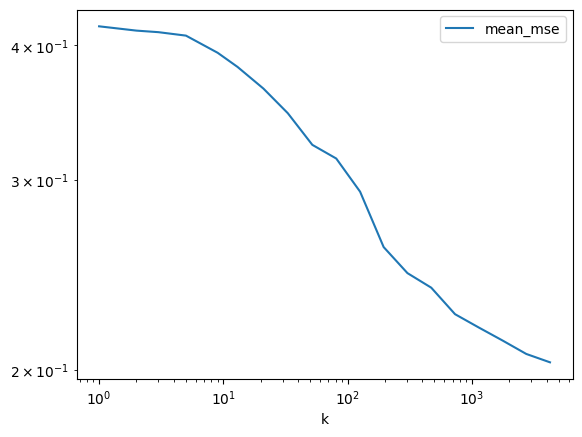

In [8]:
summary.plot(x='k', y='mean_mse', loglog=True)

In [10]:
def power_law(n, C, alpha, epsilon):
    return C* n **(-alpha) + epsilon

In [14]:
from scipy.optimize import curve_fit

k = summary["k"].values
mse = summary["mean_mse"].values

p0 = [
    max(mse) - min(mse),
    0.5,
    min(mse)
]

params, _ = curve_fit(power_law, k, mse, p0=p0, maxfev=10000)

C_hat, alpha_hat, epsilon_hat = params

In [15]:
print("C:", C_hat)
print("alpha:", alpha_hat)
print("epsilon (asymptote):", epsilon_hat)

C: 365.3920662668954
alpha: 8.507451302374328e-05
epsilon (asymptote): -364.9478820710385


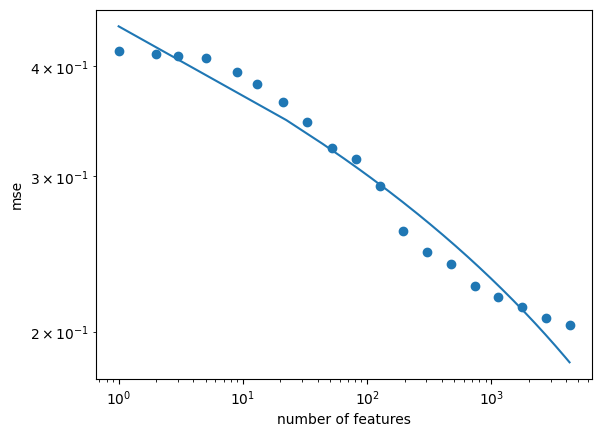

In [18]:
import numpy as np
n_smooth = np.linspace(min(k), max(k), 200)

plt.scatter(k, mse, label="data")
plt.plot(n_smooth, power_law(n_smooth, *params), label="fit")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("number of features")
plt.ylabel("mse")
plt.show()

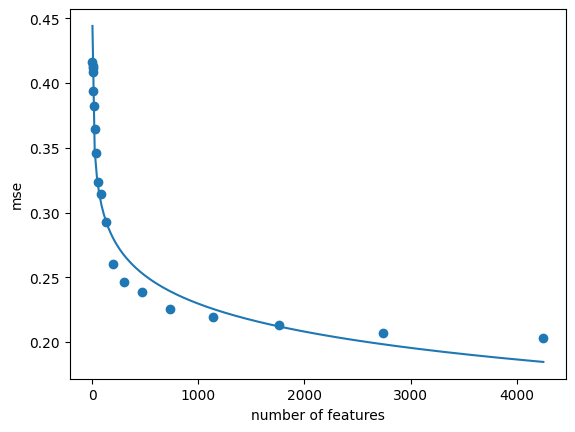

In [19]:
plt.scatter(k, mse, label="data")
plt.plot(n_smooth, power_law(n_smooth, *params), label="fit")
plt.xlabel("number of features")
plt.ylabel("mse")
plt.show()

In [20]:
# fit something else ?
def shifted_power_law(n, C, alpha, epsilon, d):
    return C * (n + d) ** (-alpha) + epsilon

In [22]:
def exp_decay(n, A, k, epsilon):
    return A * np.exp(-k * n) + epsilon

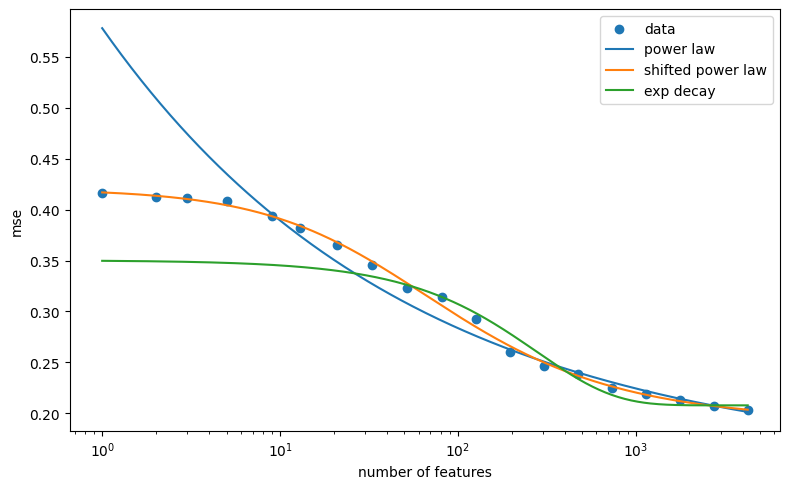

power law params: [0.42923458 0.25175568 0.14895053]
shifted power law params: [ 2.73417098  0.66080415  0.19268763 43.01890632]
exp decay params: [0.14245863 0.00359297 0.20778896]


In [24]:

# -----------------------------
# fit models
# -----------------------------

# optional weighting so large-n points matter more
weights = 1 / np.sqrt(k)

# initial guesses help optimization a lot
p0_power = [1.0, 0.5, 0.18]
p0_shift = [1.0, 0.5, 0.18, 10.0]
p0_exp = [0.25, 0.001, 0.18]

params_power, _ = curve_fit(
    power_law,
    k,
    mse,
    p0=p0_power,
    sigma=weights,
    absolute_sigma=False,
    maxfev=10000
)

params_shift, _ = curve_fit(
    shifted_power_law,
    k,
    mse,
    p0=p0_shift,
    sigma=weights,
    absolute_sigma=False,
    maxfev=10000
)

params_exp, _ = curve_fit(
    exp_decay,
    k,
    mse,
    p0=p0_exp,
    sigma=weights,
    absolute_sigma=False,
    maxfev=10000
)

# -----------------------------
# smooth curves
# -----------------------------

n_smooth = np.logspace(np.log10(min(k)), np.log10(max(k)), 400)

# predictions
y_power = power_law(n_smooth, *params_power)
y_shift = shifted_power_law(n_smooth, *params_shift)
y_exp = exp_decay(n_smooth, *params_exp)

# -----------------------------
# plot
# -----------------------------

plt.figure(figsize=(8, 5))

plt.scatter(k, mse, label="data")

plt.plot(n_smooth, y_power, label="power law")
plt.plot(n_smooth, y_shift, label="shifted power law")
plt.plot(n_smooth, y_exp, label="exp decay")

plt.xscale("log")
# try commenting this out too
# plt.yscale("log")

plt.xlabel("number of features")
plt.ylabel("mse")

plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# print parameters
# -----------------------------

print("power law params:", params_power)
print("shifted power law params:", params_shift)
print("exp decay params:", params_exp)

In [ ]:
# shifted power law seems the best 
